**Tripp formula:** $\mu_{\rm obs} = m_B + \alpha\, x_1 - \beta\, c + \gamma/2 - \text{biasCor}_{\mu} - M_B$. Residual = μ_obs − μ_theory. Alpha and beta enter through μ_obs. No biasCor.

**CPL (Chevallier–Polarski–Linder):** Dark energy equation of state evolves as $w(z) = w_0 + w_a \frac{z}{1+z}$. fitting 7 parameters: $\Omega_m$, $w_0$, $w_a$, $M_B$, $\alpha$, $\beta$, $\gamma$ (fixed $H_0$).

## 1. Install and get data

In [11]:
!pip install -q emcee corner

In [12]:
import os
# Data from local DESSN5YR 
DATA_DIR = os.path.join(os.getcwd(), "DES-SN5YR", "4_DISTANCES_COVMAT")
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join(os.getcwd(), "MCMC main", "colab", "DES-SN5YR", "4_DISTANCES_COVMAT")

## 2. Load data and config

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import emcee
import corner

DATA_FILE = DATA_DIR + "/DES-Dovekie_HD.csv"
COV_FILE = DATA_DIR + "/STAT+SYS.npz"
H0_FIXED = 70.0
N_WALKERS = 64
N_STEPS = 10000
BURN_IN_FRAC = 0.2
C_KM = 299792.458

PRIORS = {"Omega_m": (0.1, 0.6), "w0": (-3.0, 0.0), "wa": (-3.0, 2.0), "M_B": (-31.0, -18.0), "alpha": (0.0, 0.3), "beta": (0.0, 5.0), "gamma": (-0.05, 0.08)}
FIDUCIAL = [0.33, -1.0, 0.0, -29.96210, 0.169, 3.14, 0.033]  # Omega_m, w0, wa, M_B, alpha, beta, gamma

def load_snana_csv(filepath):
    var_names, rows = None, []
    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"): continue
            if line.startswith("VARNAMES:"):
                var_names = line.replace("VARNAMES:", "").split()
                continue
            if line.startswith("SN:"):
                values = line.replace("SN:", "").split()
                if var_names and len(values) >= len(var_names):
                    rows.append(values[:len(var_names)])
    df = pd.DataFrame(rows, columns=var_names)
    for col in df.columns:
        if col != "CID": df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def load_cov_npz(filepath):
    d = np.load(filepath)
    n = int(d["nsn"][0])
    inv_cov = np.zeros((n, n))
    inv_cov[np.triu_indices(n)] = d["cov"]
    inv_cov[np.tril_indices(n, -1)] = inv_cov.T[np.tril_indices(n, -1)]
    return inv_cov

# HD file: z, cov, order for covariance
df = load_snana_csv(DATA_FILE)
mask = df["zHD"] > 0
df = df[mask].reset_index(drop=True)
z = df["zHD"].values
mu_err = df["MUERR"].values
inv_cov = load_cov_npz(COV_FILE)
inv_cov = inv_cov[mask][:, mask]

# Metadata: x0, x1, c, biasCor_mu, HOST_LOGMASS (merge on CID)
df_meta = load_snana_csv(DATA_DIR + "/DES-Dovekie_Metadata.csv")
df = df.merge(df_meta[["CID", "x0", "x1", "c", "biasCor_mu", "HOST_LOGMASS"]], on="CID", how="left")

# mB from flux amplitude x0:
mB = -2.5 * np.log10(df["x0"].values)
df["mB"] = mB
x1 = df["x1"].values
c  = df["c"].values
biasCor_mu = df["biasCor_mu"].values
logmass = np.asarray(df["HOST_LOGMASS"].values, dtype=float)
has_mass = np.isfinite(logmass) & (logmass > 0) & (logmass < 15)
print(f"Loaded {len(z)} SNe. MU = mB + alpha*x1 - beta*c + gamma_term - biasCor_mu - M_B")

Loaded 1820 SNe. MU = mB + alpha*x1 - beta*c + gamma_term - biasCor_mu - M_B


## 3. Define μ_obs from Tripp formula

In [14]:
def mu_tripp(alpha, beta, gamma, M_B):
    gamma_term = np.where(
        has_mass,
        np.where(logmass >= 10.0, -gamma / 2.0, gamma / 2.0),
        0.0,
    )
    return mB + (alpha * x1) - (beta * c) + gamma_term - biasCor_mu - M_B

_, _, _, M_B_fid, alpha_fid, beta_fid, gamma_fid = FIDUCIAL
df["mu_obs"] = mu_tripp(alpha_fid, beta_fid, gamma_fid, M_B_fid)
print("MU = mB + alpha*x1 - beta*c + gamma_term - biasCor_mu - M_B (gamma_term: +gamma/2 if logmass<10, -gamma/2 if logmass>=10; 0 if no mass)")
print(f"SNe with valid host mass: {has_mass.sum()} out of {len(logmass)}")
print(df[["mB", "x1", "c", "mu_obs"]].head())

MU = mB + alpha*x1 - beta*c + gamma_term - biasCor_mu - M_B (gamma_term: +gamma/2 if logmass<10, -gamma/2 if logmass>=10; 0 if no mass)
SNe with valid host mass: 1820 out of 1820
         mB        x1         c     mu_obs
0  5.335491  1.326600  0.081603  35.293852
1  5.488854 -2.172020  0.037129  35.046499
2  4.968824 -0.168780 -0.021597  35.012916
3  5.266236 -0.951968  0.010597  35.102278
4  5.345791  0.380730  0.084174  35.184027


## 4. Cosmology and likelihood (residual = mu_obs - mu_theory)


In [15]:
def distance_modulus(z, Omega_m, w0, wa, H0):
    Omega_de = 1.0 - Omega_m
    def E(zp):
        de_term = Omega_de * (1 + zp)**(3*(1 + w0 + wa)) * np.exp(-3 * wa * zp / (1 + zp))
        return np.sqrt(Omega_m * (1 + zp)**3 + de_term)
    z_vals = np.atleast_1d(z)
    z_max = float(z_vals.max())
    n_grid = 400
    z_grid = np.linspace(0, z_max, n_grid)
    E_grid = E(z_grid)
    integrand = 1.0 / E_grid
    D_grid = np.concatenate([[0], np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * np.diff(z_grid))])
    d_c = C_KM * np.interp(z_vals, z_grid, D_grid) / H0
    out = 5.0 * np.log10((1 + z_vals) * d_c) + 25.0
    return float(out[0]) if np.isscalar(z) else out

def log_prior(theta):
    Omega_m, w0, wa, M_B, alpha, beta, gamma = theta
    if not (PRIORS["Omega_m"][0] < Omega_m < PRIORS["Omega_m"][1]): return -np.inf
    if not (PRIORS["w0"][0] < w0 < PRIORS["w0"][1]): return -np.inf
    if not (PRIORS["wa"][0] < wa < PRIORS["wa"][1]): return -np.inf
    if not (PRIORS["M_B"][0] < M_B < PRIORS["M_B"][1]): return -np.inf
    if not (PRIORS["alpha"][0] < alpha < PRIORS["alpha"][1]): return -np.inf
    if not (PRIORS["beta"][0] < beta < PRIORS["beta"][1]): return -np.inf
    if not (PRIORS["gamma"][0] < gamma < PRIORS["gamma"][1]): return -np.inf
    
     # CMB Gaussian prior on Omega_m (Planck 2018)
    log_p_Om = -0.5 * ((Omega_m - 0.315) / 0.007) ** 2

    return log_p_Om


def log_likelihood(theta):
    Omega_m, w0, wa, M_B, alpha, beta, gamma = theta
    mu_tripp_now = mu_tripp(alpha, beta, gamma, M_B)
    mu_theory = distance_modulus(z, Omega_m, w0, wa, H0_FIXED)
    residuals = mu_tripp_now - mu_theory
    return -0.5 * (residuals @ inv_cov @ residuals)

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp): return -np.inf
    return lp + log_likelihood(theta)

## 5. Run MCMC

In [16]:
n_dim = 7  # Omega_m, w0, wa, M_B, alpha, beta, gamma
theta0 = np.array(FIDUCIAL)
pos = theta0 + 1e-3 * np.random.randn(N_WALKERS, n_dim)
sampler = emcee.EnsembleSampler(N_WALKERS, n_dim, log_posterior)
sampler.run_mcmc(pos, N_STEPS, progress=True)
chains = sampler.get_chain()
print("MCMC complete")

100%|██████████| 10000/10000 [37:25<00:00,  4.45it/s] 

MCMC complete


## 6. Results and residual plot

In [17]:
param_names = ["Omega_m", "w0", "wa", "M_B", "alpha", "beta", "gamma"]
burn_in = int(BURN_IN_FRAC * N_STEPS)
flat = chains[burn_in:].reshape(-1, n_dim)
results = {}
for i, name in enumerate(param_names):
    s = flat[:, i]
    med = np.median(s)
    lo, hi = np.percentile(s, 16), np.percentile(s, 84)
    results[name] = {"median": med, "lower": med - lo, "upper": hi - med}
print("68% C.I.:")
for name in param_names:
    r = results[name]
    print(f"  {name}: {r['median']:.4f} +{r['upper']:.4f} -{r['lower']:.4f}")

68% C.I.:
  Omega_m: 0.3160 +0.0070 -0.0071
  w0: -0.8277 +0.1135 -0.1134
  wa: -0.8095 +0.6743 -0.6748
  M_B: -29.9406 +0.0147 -0.0146
  alpha: 0.1688 +0.0041 -0.0041
  beta: 3.1220 +0.0557 -0.0558
  gamma: -0.0390 +0.0090 -0.0071


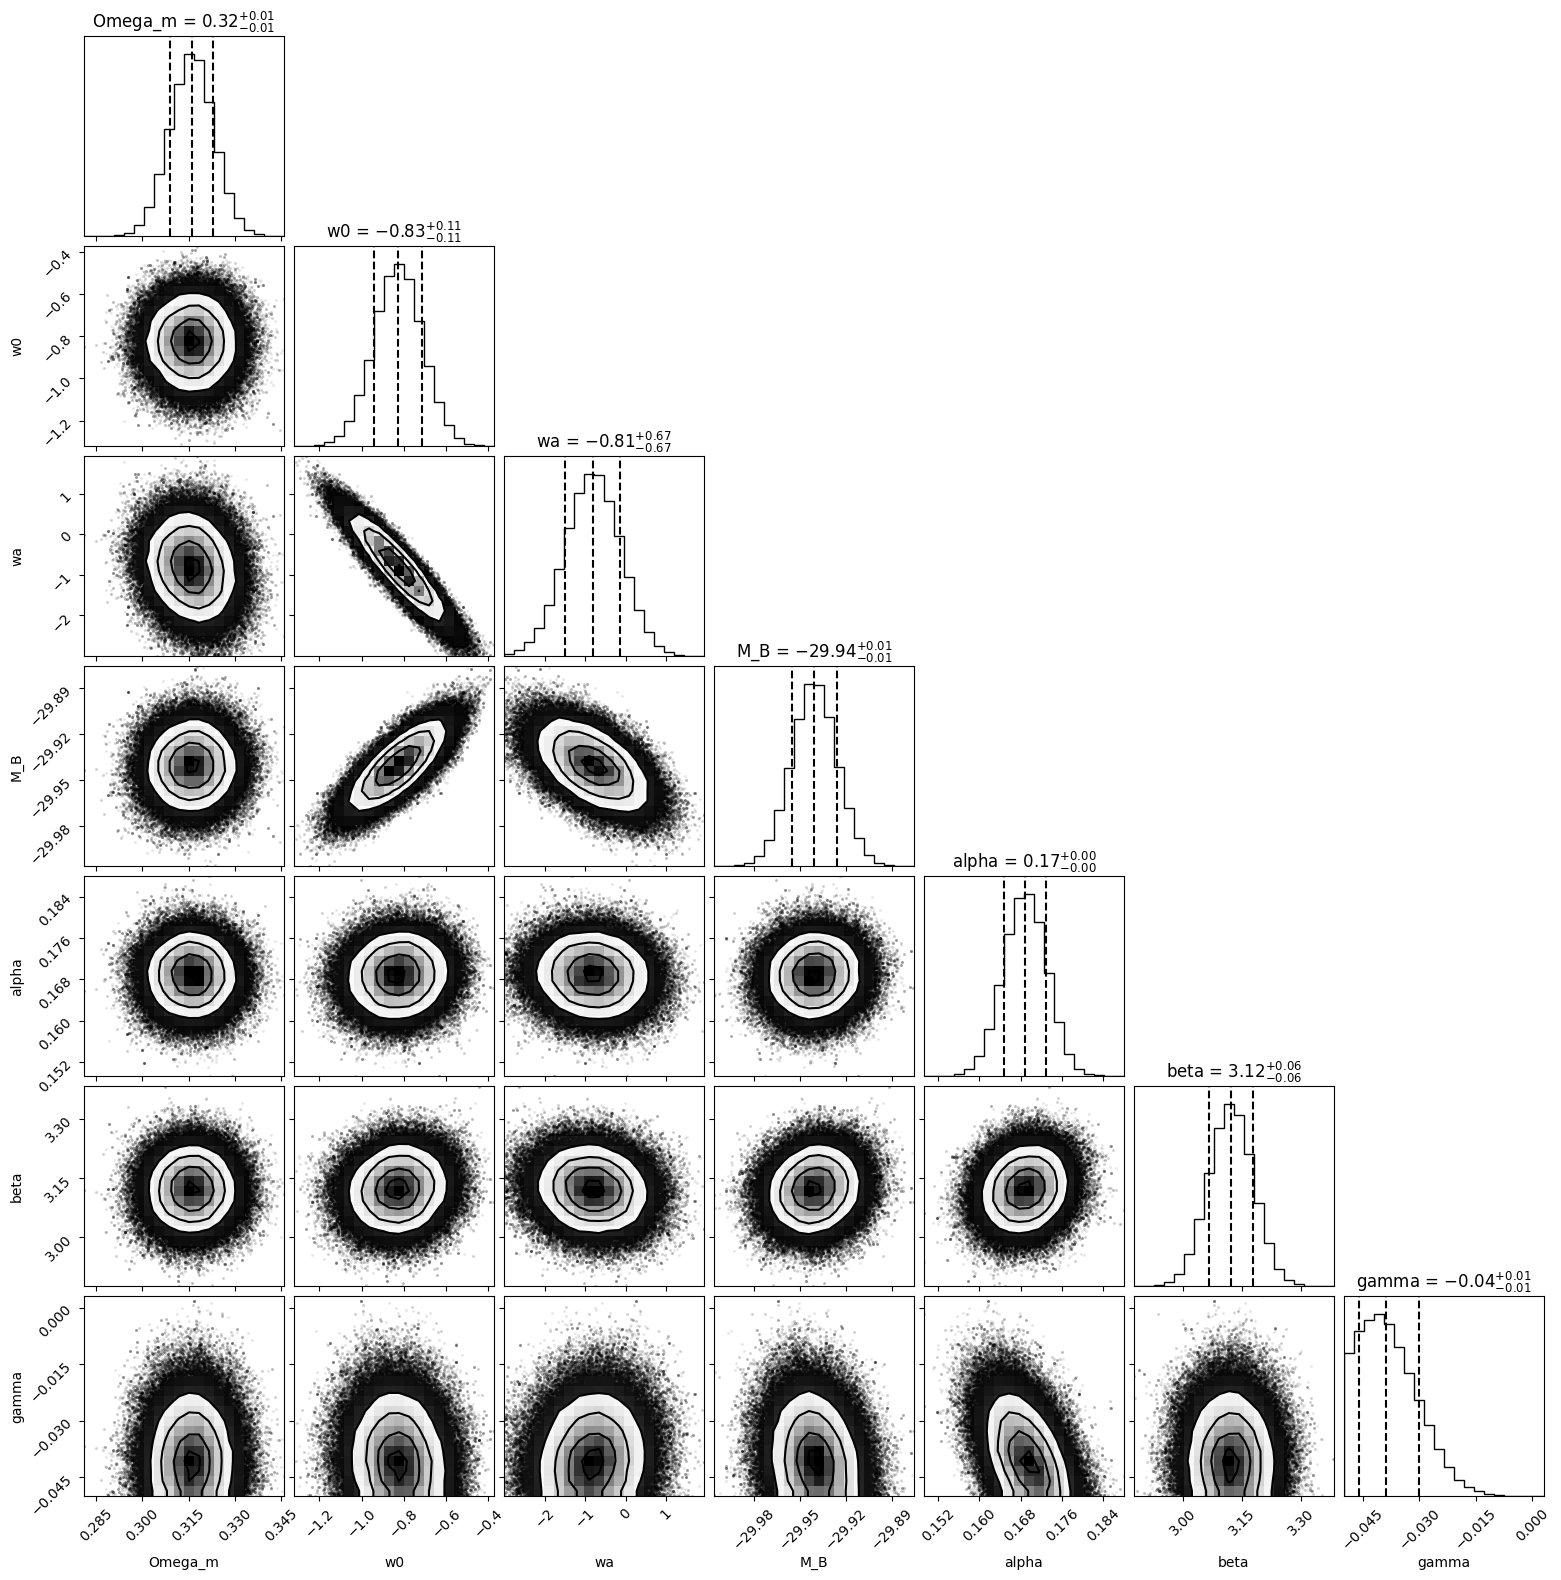

In [19]:
fig = corner.corner(flat, labels=param_names, quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()